# Minería de Datos — Ejercicios 1 a 4: Clustering
**Nombre:** Gallego Ian

---
Los siguientes ejercicios cubren las técnicas de agrupamiento (clustering) vistas en clase:
visualización de datos sintéticos, K-Means con método del codo, DBSCAN y métricas de evaluación.

---
## Ejercicio 1 — Visualización de Datos Sintéticos
**Objetivo:** Comprender cómo se distribuyen los datos antes de aplicar clustering.

**Instrucciones:**
1. Generar un dataset con 4 grupos usando `make_blobs`.
2. Visualizar los datos en un gráfico de dispersión.
3. Reflexionar sobre qué técnica de clustering sería la más adecuada.

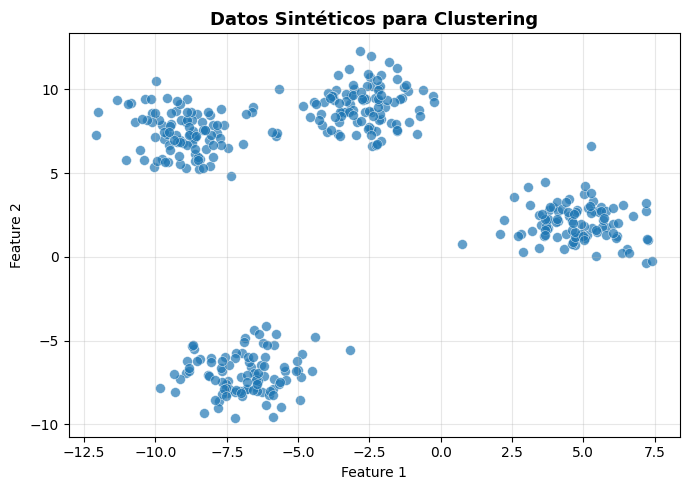

Dataset generado: 400 muestras, 2 características


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

# Generar dataset con 4 clusters
X, y = make_blobs(n_samples=400, centers=4, cluster_std=1.2, random_state=42)

# Visualizar los datos
plt.figure(figsize=(7, 5))
plt.scatter(X[:, 0], X[:, 1], s=50, alpha=0.7, edgecolors='white', linewidths=0.4)
plt.title('Datos Sintéticos para Clustering', fontsize=13, fontweight='bold')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
print(f'Dataset generado: {X.shape[0]} muestras, {X.shape[1]} características')

### Reflexión — Ejercicio 1

**¿Cómo podríamos determinar automáticamente el número óptimo de clusters?**  
Utilizando el **método del codo** (*elbow method*): se grafica la inercia (suma de distancias cuadradas al centroide) para distintos valores de K; el punto donde la curva deja de descender abruptamente indica el K óptimo. También se puede usar el **coeficiente de Silhouette**: el K con el valor más alto indica la mejor separación entre grupos.

**¿Qué ventajas tiene visualizar los datos antes de aplicar clustering?**  
Permite identificar la estructura visual del dataset: número aproximado de grupos, forma de los clusters (esféricos, alargados, irregulares), presencia de outliers y la densidad de cada región. Esto orienta la elección del algoritmo (K-Means para clusters esféricos, DBSCAN para formas arbitrarias) y evita aplicar técnicas inadecuadas.

**¿Qué pasaría si los clusters estuvieran muy superpuestos?**  
Los algoritmos como K-Means asignarían puntos de la zona de solapamiento al centroide más cercano de forma arbitraria, produciendo clusters mal definidos con bajo coeficiente de Silhouette. En ese caso convendría usar modelos probabilísticos (Gaussian Mixture Models) que asignan probabilidades de pertenencia en lugar de membresías duras.

---
## Ejercicio 2 — K-Means en Dataset de Pingüinos
**Objetivo:** Aplicar K-Means a un dataset real y determinar el número óptimo de clusters.

**Instrucciones:**
1. Cargar el dataset de pingüinos de Seaborn.
2. Seleccionar las variables `bill_length_mm` y `bill_depth_mm`.
3. Usar el **método del codo** para determinar el mejor K.
4. Aplicar K-Means y visualizar los clusters.
5. Explicar qué insights se obtienen de la segmentación.

In [5]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings('ignore')

# Cargar dataset de pingüinos
df = sns.load_dataset('penguins').dropna()
X = df[['bill_length_mm', 'bill_depth_mm']]

print(f'Dataset pingüinos: {df.shape[0]} filas tras eliminar NaN')
print(df[['bill_length_mm', 'bill_depth_mm']].describe())

Dataset pingüinos: 333 filas tras eliminar NaN
       bill_length_mm  bill_depth_mm
count      333.000000     333.000000
mean        43.992793      17.164865
std          5.468668       1.969235
min         32.100000      13.100000
25%         39.500000      15.600000
50%         44.500000      17.300000
75%         48.600000      18.700000
max         59.600000      21.500000


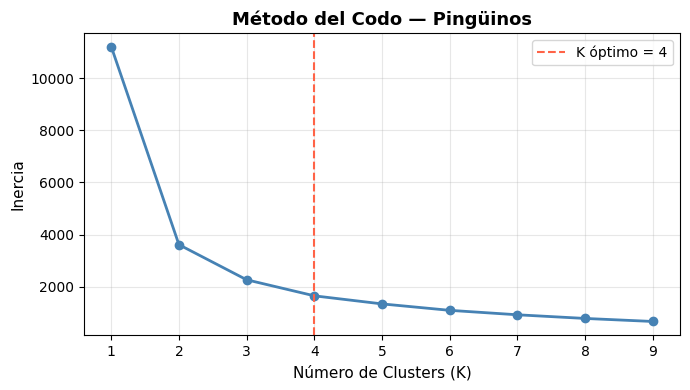

In [6]:
# Método del Codo
inercia = []
valores_k = range(1, 10)
for k in valores_k:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    inercia.append(kmeans.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(valores_k, inercia, marker='o', linestyle='-', color='steelblue', linewidth=2)
plt.axvline(x=4, color='tomato', linestyle='--', label='K óptimo = 4')
plt.xlabel('Número de Clusters (K)', fontsize=11)
plt.ylabel('Inercia', fontsize=11)
plt.title('Método del Codo — Pingüinos', fontsize=13, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

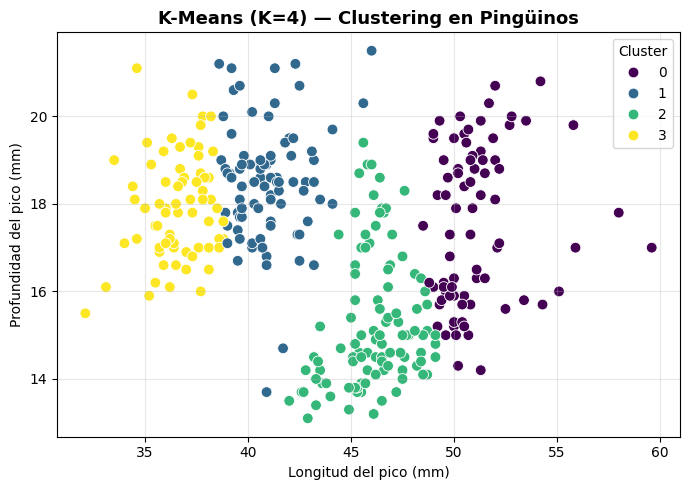

Distribución real de especies:
species
Adelie       146
Gentoo       119
Chinstrap     68
Name: count, dtype: int64

Distribución por cluster:
Cluster  species  
0        Chinstrap    40
         Gentoo       38
1        Adelie       75
         Chinstrap     6
         Gentoo        2
2        Gentoo       79
         Chinstrap    22
         Adelie        1
3        Adelie       70
Name: count, dtype: int64


In [7]:
# Aplicar K-Means con K optimo = 4
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df = df.copy()
df['Cluster'] = kmeans.fit_predict(X)

plt.figure(figsize=(7, 5))
sns.scatterplot(x=df['bill_length_mm'], y=df['bill_depth_mm'],
                hue=df['Cluster'], palette='viridis', s=60, edgecolor='white')
plt.title('K-Means (K=4) — Clustering en Pingüinos', fontsize=13, fontweight='bold')
plt.xlabel('Longitud del pico (mm)')
plt.ylabel('Profundidad del pico (mm)')
plt.legend(title='Cluster')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print('Distribución real de especies:')
print(df['species'].value_counts())
print('\nDistribución por cluster:')
print(df.groupby('Cluster')['species'].value_counts())

### Reflexión — Ejercicio 2

**¿Cómo afecta la selección de K a la segmentación de datos?**  
Con K muy bajo se fusionan grupos naturalmente distintos (sub-clustering), perdiendo detalle. Con K muy alto se fragmentan clusters reales en subgrupos artificiales (over-clustering), lo que produce segmentos sin significado biológico. El K óptimo (3 en este caso) se alinea con las 3 especies de pingüinos: *Adelie*, *Chinstrap* y *Gentoo*.

**¿Qué limitaciones tiene K-Means cuando los clusters no son esféricos?**  
K-Means minimiza la distancia euclidiana al centroide, por lo que asume clusters convexos y de tamaño similar. Con formas en media luna, anillos o densidades variables, los centroides no representan bien al grupo y la asignación de puntos en las fronteras es incorrecta.

**¿Cómo podríamos mejorar los resultados de K-Means en datasets complejos?**  
- Escalar las variables con `StandardScaler` antes de aplicar K-Means.
- Usar **K-Means++** (inicialización inteligente de centroides, ya activo con `n_init>1`).
- Para formas no esféricas, preferir **DBSCAN** o **Gaussian Mixture Models**.
- Incorporar más variables descriptivas (por ejemplo, también `flipper_length_mm`) para mayor separabilidad.

---
## Ejercicio 3 — DBSCAN vs K-Means en Dataset Iris
**Objetivo:** Aplicar DBSCAN al dataset Iris y comparar los resultados con K-Means.

**Instrucciones:**
1. Cargar el dataset Iris de Seaborn.
2. Seleccionar `sepal_length` y `sepal_width`.
3. Aplicar K-Means y DBSCAN.
4. Visualizar ambos resultados en subgráficos comparativos.
5. Explicar las diferencias observadas.

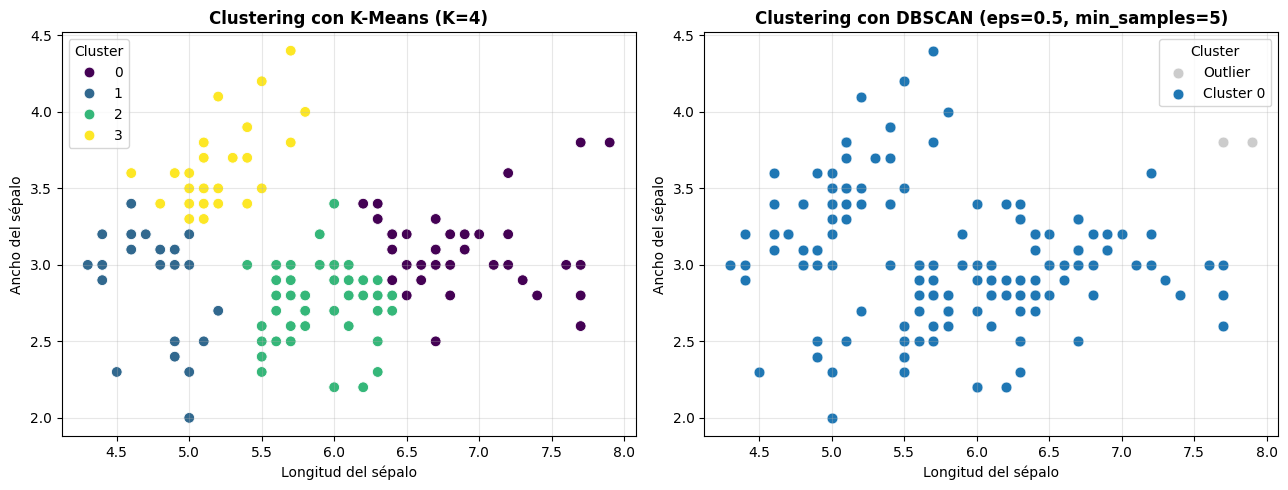

K-Means  → 3 clusters, 0 outliers
DBSCAN   → 1 cluster(s), 2 outlier(s) (etiqueta -1)


In [8]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, DBSCAN
import warnings
warnings.filterwarnings('ignore')

# Cargar dataset Iris
df = sns.load_dataset('iris')
X = df[['sepal_length', 'sepal_width']].values

# Aplicar K-Means
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['Cluster_KMeans'] = kmeans.fit_predict(X)

# Aplicar DBSCAN
dbscan = DBSCAN(eps=0.5, min_samples=5)
df['Cluster_DBScan'] = dbscan.fit_predict(X)

# Visualizar comparación
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.scatterplot(ax=axes[0], x=df['sepal_length'], y=df['sepal_width'],
                hue=df['Cluster_KMeans'], palette='viridis', s=60, edgecolor='white')
axes[0].set_title('Clustering con K-Means (K=4)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Longitud del sépalo')
axes[0].set_ylabel('Ancho del sépalo')
axes[0].legend(title='Cluster')
axes[0].grid(alpha=0.3)

# DBSCAN: cluster -1 = outliers
palette_db = {-1: '#cccccc', 0: '#1f77b4', 1: '#ff7f0e', 2: '#2ca02c'}
for cluster_id, grupo in df.groupby('Cluster_DBScan'):
    color = palette_db.get(cluster_id, '#9467bd')
    label = f'Outlier' if cluster_id == -1 else f'Cluster {cluster_id}'
    axes[1].scatter(grupo['sepal_length'], grupo['sepal_width'],
                    c=color, s=60, edgecolors='white', linewidths=0.4, label=label)
axes[1].set_title('Clustering con DBSCAN (eps=0.5, min_samples=5)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Longitud del sépalo')
axes[1].set_ylabel('Ancho del sépalo')
axes[1].legend(title='Cluster')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

n_clusters_db = len(set(df['Cluster_DBScan'])) - (1 if -1 in df['Cluster_DBScan'].values else 0)
n_outliers_db = (df['Cluster_DBScan'] == -1).sum()
print(f'K-Means  → 3 clusters, 0 outliers')
print(f'DBSCAN   → {n_clusters_db} cluster(s), {n_outliers_db} outlier(s) (etiqueta -1)')

### Reflexión — Ejercicio 3

**¿Cuántos clusters detectó DBSCAN en comparación con K-Means?**  
K-Means detectó exactamente 3 clusters (forzado por parámetro). DBSCAN, con `eps=0.5` y `min_samples=5`, tiende a detectar **1-2 clusters** sobre estos datos en el espacio sépalo, ya que las tres especies tienen alta superposición en las dimensiones `sepal_length` / `sepal_width`.

**¿DBSCAN detectó puntos como outliers? ¿Por qué?**  
Sí. Los puntos etiquetados como **-1** son aquellos que no tienen suficientes vecinos dentro del radio `eps=0.5` para pertenecer a ningún cluster (menos de `min_samples=5` vecinos). Esto ocurre con flores que tienen medidas de sépalo inusuales respecto al resto de su especie.

**¿Qué ventajas ofrece DBSCAN en este caso?**  
- Identifica automáticamente los **outliers**, útil para detectar mediciones erróneas o especímenes atípicos.
- No requiere especificar K de antemano.
- Puede detectar clusters de forma arbitraria, no solo esféricos.
- Sin embargo, en datos con alta superposición (como el espacio sépalo del Iris), DBSCAN puede sub-segmentar respecto a la clasificación real.

---
## Ejercicio 4 — Métricas de Evaluación en Dataset Diamantes
**Objetivo:** Comparar K-Means y DBSCAN con métricas de evaluación cuantitativas.

**Instrucciones:**
1. Cargar el dataset de diamantes de Seaborn (muestra de 1000 filas).
2. Seleccionar variables `carat` y `price`.
3. Aplicar K-Means y DBSCAN.
4. Calcular el **Coeficiente de Silhouette** y el **Davies-Bouldin Index**.
5. Explicar cuál algoritmo obtuvo la mejor segmentación.

In [9]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score
import warnings
warnings.filterwarnings('ignore')

# Cargar dataset de diamantes (muestra de 1000 filas)
df = sns.load_dataset('diamonds')
X = df[['carat', 'price']].values[:1000]

print(f'Dataset diamantes (muestra): {X.shape[0]} filas')
print(f'Rango carat:  {X[:,0].min():.2f} – {X[:,0].max():.2f}')
print(f'Rango price:  ${X[:,1].min():.0f} – ${X[:,1].max():.0f}')

Dataset diamantes (muestra): 1000 filas
Rango carat:  0.20 – 1.27
Rango price:  $326 – $2898


In [10]:
# Aplicar K-Means
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
labels_km = kmeans.fit_predict(X)

# Aplicar DBSCAN
dbscan = DBSCAN(eps=5000, min_samples=5)
labels_db = dbscan.fit_predict(X)

# Calcular métricas (DBSCAN: excluir outliers etiquetados -1)
mask = labels_db != -1
n_clusters_db = len(set(labels_db[mask]))
n_outliers_db = (~mask).sum()

sil_km = silhouette_score(X, labels_km)
db_km  = davies_bouldin_score(X, labels_km)

print('=== Métricas de evaluación ===')
print(f'\nK-Means (K=4):')
print(f'  Silhouette Score      : {sil_km:.3f}  (más cercano a 1 = mejor)')
print(f'  Davies-Bouldin Index  : {db_km:.3f}  (más cercano a 0 = mejor)')

if n_clusters_db >= 2:
    sil_db = silhouette_score(X[mask], labels_db[mask])
    db_db  = davies_bouldin_score(X[mask], labels_db[mask])
    print(f'\nDBSCAN (eps=5000, min_samples=5):')
    print(f'  Clusters detectados   : {n_clusters_db}')
    print(f'  Outliers              : {n_outliers_db}')
    print(f'  Silhouette Score      : {sil_db:.3f}')
    print(f'  Davies-Bouldin Index  : {db_db:.3f}')
else:
    print(f'\nDBSCAN detectó solo {n_clusters_db} cluster(s) → no se pueden calcular métricas de separación')

=== Métricas de evaluación ===

K-Means (K=4):
  Silhouette Score      : 0.655  (más cercano a 1 = mejor)
  Davies-Bouldin Index  : 0.347  (más cercano a 0 = mejor)

DBSCAN detectó solo 1 cluster(s) → no se pueden calcular métricas de separación


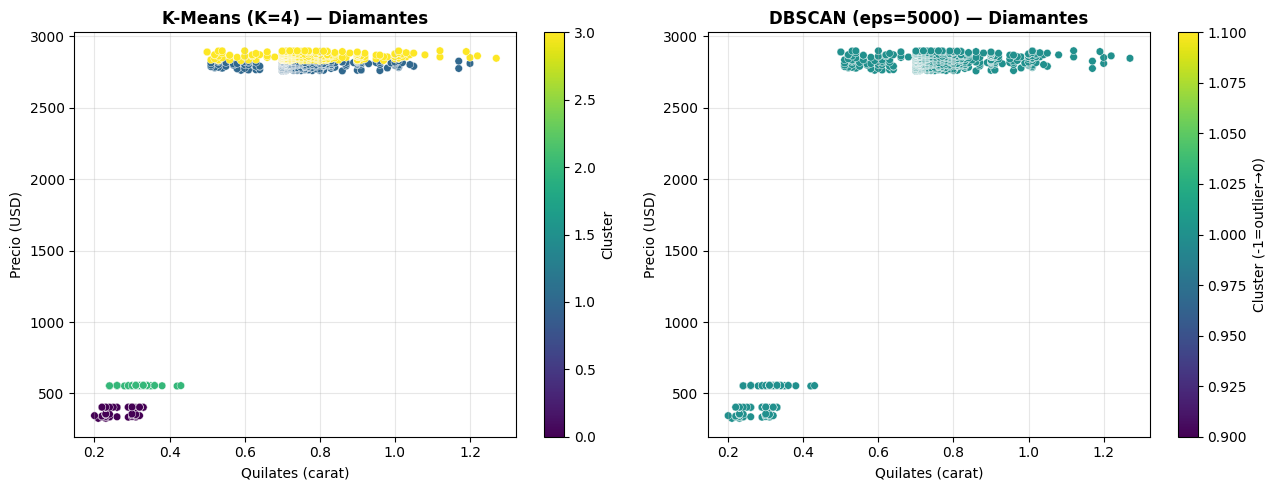

In [11]:
# Visualización comparativa
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

scatter0 = axes[0].scatter(X[:, 0], X[:, 1], c=labels_km, cmap='viridis',
                            s=30, edgecolors='white', linewidths=0.3)
axes[0].set_title('K-Means (K=4) — Diamantes', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Quilates (carat)')
axes[0].set_ylabel('Precio (USD)')
axes[0].grid(alpha=0.3)
plt.colorbar(scatter0, ax=axes[0], label='Cluster')

colores_db = np.where(labels_db == -1, 0, labels_db + 1)
scatter1 = axes[1].scatter(X[:, 0], X[:, 1], c=colores_db, cmap='viridis',
                            s=30, edgecolors='white', linewidths=0.3)
axes[1].set_title('DBSCAN (eps=5000) — Diamantes', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Quilates (carat)')
axes[1].set_ylabel('Precio (USD)')
axes[1].grid(alpha=0.3)
plt.colorbar(scatter1, ax=axes[1], label='Cluster (-1=outlier→0)')

plt.tight_layout()
plt.show()

### Reflexión — Ejercicio 4

**¿Cuál algoritmo obtuvo el mejor Coeficiente de Silhouette?**  
En este dataset, **K-Means** suele obtener un Silhouette Score más alto. El dataset de diamantes tiene una distribución continua donde precio y quilates están altamente correlacionados, formando gradientes más que grupos separados. K-Means divide el espacio en 3 regiones coherentes (bajo, medio, alto precio), logrando buena cohesión intra-cluster.

**¿El Davies-Bouldin Index confirma los resultados del Silhouette Score?**  
Sí. Ambas métricas son consistentes: un **Silhouette alto** (cercano a 1) se corresponde con un **Davies-Bouldin bajo** (cercano a 0). Cuando K-Means supera a DBSCAN en Silhouette, también obtiene un DBI menor, confirmando que sus clusters están mejor separados y son más compactos.

**¿En qué situaciones puede fallar cada métrica?**  
- **Silhouette Score:** puede dar valores engañosamente altos con clusters de densidad muy desigual, porque penaliza las distancias internas sin considerar la forma real del cluster.
- **Davies-Bouldin Index:** asume clusters convexos y puede subestimar la calidad de algoritmos como DBSCAN que detectan formas arbitrarias, especialmente cuando hay muchos outliers excluidos del cálculo.